In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BG       = '#F7F9FC'
ACCENT   = '#1A2E4A'
TEAL     = '#2A9D8F'
CORAL    = '#E76F51'
GOLD     = '#E9C46A'
NAVY     = '#264653'
PURPLE   = '#6A4C93'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.edgecolor'   : ACCENT,
    'axes.labelcolor'  : ACCENT,
    'xtick.color'      : ACCENT,
    'ytick.color'      : ACCENT,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

In [3]:
df = pd.read_csv('insurance.csv')
print(f'Dataset Shape  : {df.shape}')
print(f'Rows           : {df.shape[0]:,}')
print(f'Columns        : {df.shape[1]}')
df.head()

Dataset Shape  : (1338, 7)
Rows           : 1,338
Columns        : 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Card: Insurance Dataset

## **Dataset Overview**
- **Name**: Insurance Claims / Medical Cost Dataset
- **Source**: Provided CSV file (`insurance.csv`)
- **Format**: Flat CSV (Single Sheet)
- **Rows**: 1,338
- **Columns**: 7
- **Target Variable**: `charges` (Continuous — Medical Insurance Charges)

**Business Context**: This dataset is typically used to predict individual medical insurance charges based on demographic and health-related attributes.

---

## **Column Description**

| Column       | Description                                      | Type          | Notes |
|--------------|--------------------------------------------------|---------------|-------|
| `age`        | Age of the primary beneficiary                   | Numeric       | 18–64 years |
| `sex`        | Gender of the insurance holder                   | Categorical   | male / female |
| `bmi`        | Body Mass Index (weight in kg / height in m²)    | Numeric       | Important health indicator |
| `children`   | Number of children / dependents                  | Numeric       | 0–5 |
| `smoker`     | Whether the beneficiary smokes                   | Categorical   | yes / no (Strong predictor) |
| `region`     | Residential area in the US                       | Categorical   | northeast, northwest, southeast, southwest |
| `charges`    | Individual medical costs billed by insurance     | Numeric (Target) | **Target Variable** |

---

## **Key Statistics**

- **Total Records**: 1,338
- **Average Age**: ~39 years
- **Smoker Rate**: ~20.5%
- **Average Charges**: ~$13,270
- **Gender Distribution**: Balanced (Male ≈ 50.5%, Female ≈ 49.5%)
- **Regions**: Four major U.S. regions represented

---

## **Data Quality Highlights**

- **Missing Values**: None (Clean dataset)
- **Data Types**: Mostly appropriate (categorical columns need encoding for modeling)
- **Potential Issues**: 
  - `charges` is highly right-skewed (high variance due to smokers and older individuals)
  - `bmi` and `age` show strong correlation with target variable
- **Outliers**: Present in `charges` (especially for smokers)

---

## **Business Objective**
Predict medical insurance charges (`charges`) based on customer attributes to support:
- Risk assessment and pricing strategies
- Identification of high-cost policyholders
- Understanding impact of smoking, BMI, and age on premiums

---

## **Class / Feature Insights**
- **Smoker** is expected to be the strongest predictor of high `charges`.
- **Age** and **BMI** have positive correlation with insurance costs.
- Regional differences may reflect varying healthcare costs.

---

**Data Card Prepared for**: Insurance Charges Analysis  
---

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
missing = df.isnull().sum()
print('Missing Value Check:')
print(missing)
print(f'\nTotal missing values : {missing.sum()}')
print('\n Dataset is 100% complete — No imputation required.')

Missing Value Check:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values : 0

 Dataset is 100% complete — No imputation required.


In [6]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [7]:
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col.upper()} Distribution:")
    print(df[col].value_counts())
    print(f"  → Unique values: {df[col].unique()}")


SEX Distribution:
sex
male      676
female    662
Name: count, dtype: int64
  → Unique values: <StringArray>
['female', 'male']
Length: 2, dtype: str

SMOKER Distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64
  → Unique values: <StringArray>
['yes', 'no']
Length: 2, dtype: str

REGION Distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
  → Unique values: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


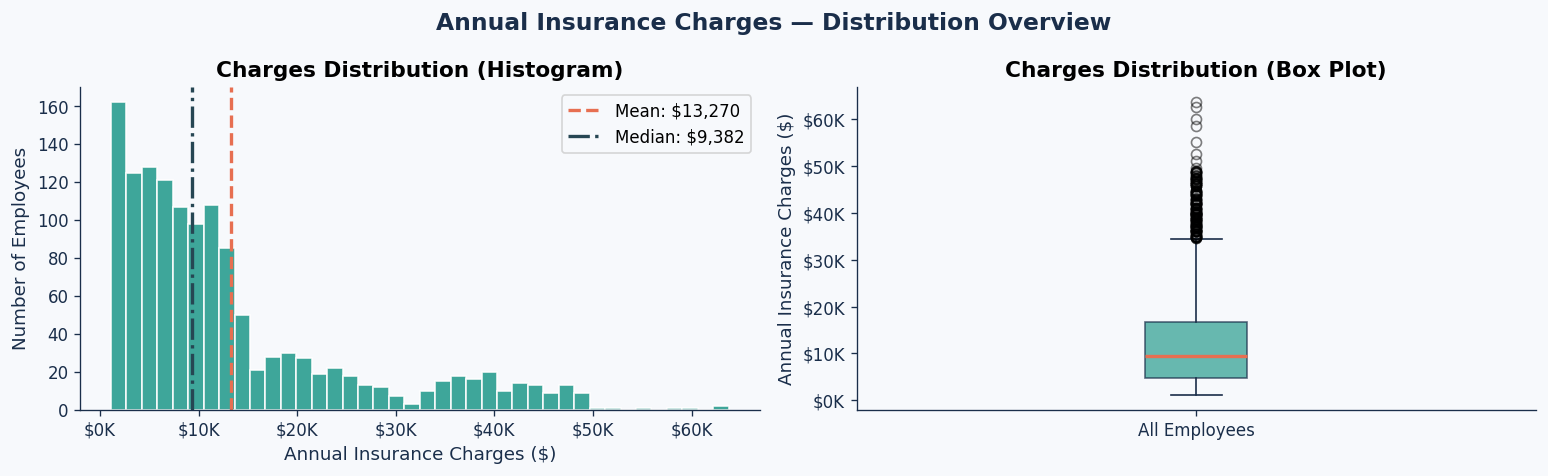

Mean   : $ 13,270.42
Median : $  9,382.03
Std Dev: $ 12,110.01
Min    : $  1,121.87
Max    : $ 63,770.43


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Annual Insurance Charges — Distribution Overview',
             fontsize=14, fontweight='bold', color=ACCENT)

axes[0].hist(df['charges'], bins=40, color=TEAL,
             edgecolor='white', alpha=0.9)
axes[0].axvline(df['charges'].mean(), color=CORAL, linewidth=2,
                linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color=NAVY, linewidth=2,
                linestyle='-.', label=f'Median: ${df["charges"].median():,.0f}')
axes[0].set_title('Charges Distribution (Histogram)', fontweight='bold')
axes[0].set_xlabel('Annual Insurance Charges ($)')
axes[0].set_ylabel('Number of Employees')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

axes[1].boxplot(df['charges'], patch_artist=True,
                boxprops=dict(facecolor=TEAL, color=ACCENT, alpha=0.7),
                medianprops=dict(color=CORAL, linewidth=2),
                whiskerprops=dict(color=ACCENT),
                capprops=dict(color=ACCENT),
                flierprops=dict(marker='o', color=CORAL, alpha=0.5))
axes[1].set_title('Charges Distribution (Box Plot)', fontweight='bold')
axes[1].set_ylabel('Annual Insurance Charges ($)')
axes[1].set_xticklabels(['All Employees'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print(f'Mean   : ${df["charges"].mean():>10,.2f}')
print(f'Median : ${df["charges"].median():>10,.2f}')
print(f'Std Dev: ${df["charges"].std():>10,.2f}')
print(f'Min    : ${df["charges"].min():>10,.2f}')
print(f'Max    : ${df["charges"].max():>10,.2f}')

### Observation

- The histogram provides an overview of the distribution of annual insurance charges across all individuals in the dataset.
- The difference between the mean and median values indicates whether the distribution is symmetric or skewed.
- A concentration of observations in lower charge ranges combined with a long right tail suggests the presence of high-cost insurance cases.
- The box plot highlights the spread of insurance charges and identifies potential outliers with exceptionally high medical expenses.
- The large gap between the minimum and maximum charges indicates substantial variability in healthcare costs among individuals.

### Business Impact

- The presence of high-cost outliers can significantly increase the overall insurance expenditure and financial risk for insurance providers.
- Understanding the distribution of charges helps insurers develop more accurate pricing and risk assessment models.
- Highly skewed charge distributions may require specialized premium structures for high-risk individuals.
- Identifying variability in insurance costs supports better budgeting, underwriting, and resource allocation decisions.
- Insights from charge distribution analysis can help insurance companies design targeted policies and improve profitability while maintaining competitive pricing.

### Executive Takeaway

Annual insurance charges exhibit considerable variation across individuals, with a small number of high-cost cases contributing disproportionately to overall expenses. Effective risk assessment and pricing strategies should therefore focus on identifying the factors associated with these high-charge individuals.

In [9]:
smoker_median = df.groupby('smoker')['charges'].median()
smoker_mean   = df.groupby('smoker')['charges'].mean()
smoker_count  = df.groupby('smoker')['charges'].count()

print('Median Annual Insurance Charges by Smoking Status:')
print(smoker_median.to_frame().rename(columns={'charges':'Median Charges ($)'}))

ratio = smoker_median['yes'] / smoker_median['no']
print(f'\n A smoking employee costs the company {ratio:.2f}x more than a non-smoker')
print(f' Median Smoker    : ${smoker_median["yes"]:,.2f}')
print(f' Median Non-Smoker: ${smoker_median["no"]:,.2f}')
print(f' Annual Excess    : ${smoker_median["yes"] - smoker_median["no"]:,.2f} per smoker per year')
print(f'\n Total Smokers in Workforce: {smoker_count["yes"]} ({smoker_count["yes"]/len(df)*100:.1f}% of headcount)')

Median Annual Insurance Charges by Smoking Status:
        Median Charges ($)
smoker                    
no              7345.40530
yes            34456.34845

 A smoking employee costs the company 4.69x more than a non-smoker
 Median Smoker    : $34,456.35
 Median Non-Smoker: $7,345.41
 Annual Excess    : $27,110.94 per smoker per year

 Total Smokers in Workforce: 274 (20.5% of headcount)


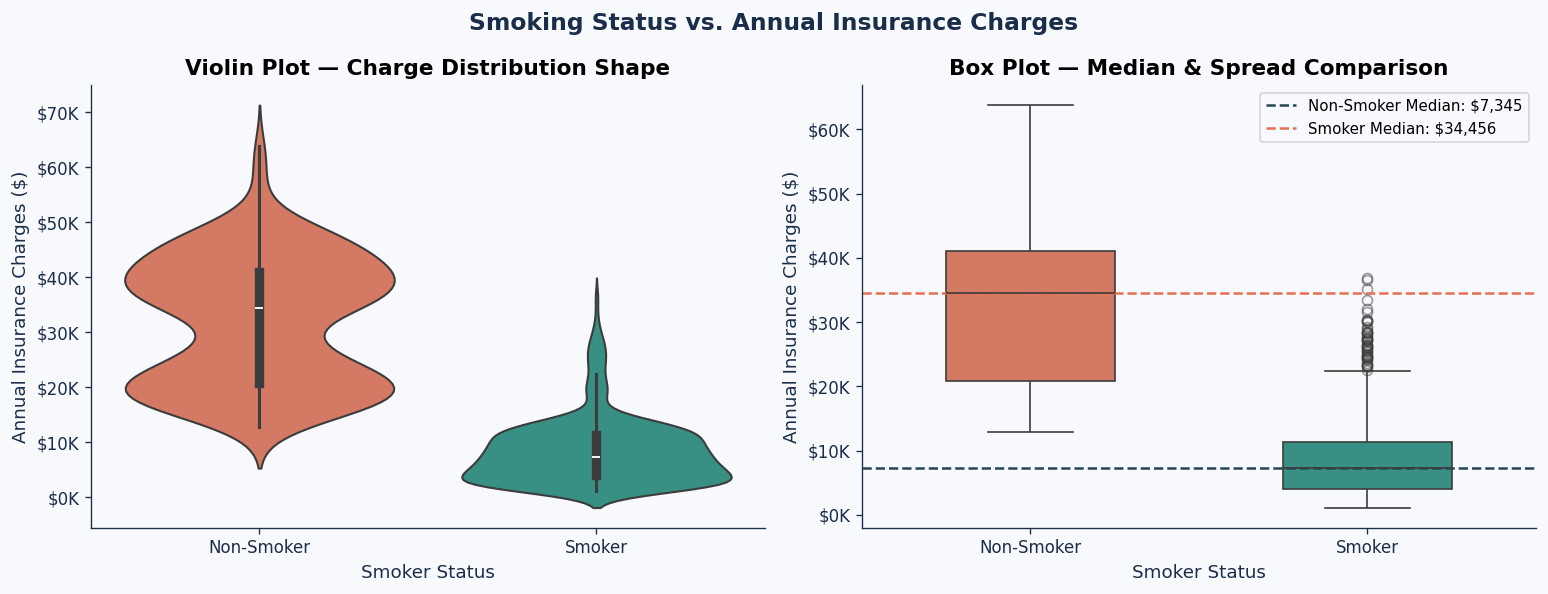

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Smoking Status vs. Annual Insurance Charges',
             fontsize=14, fontweight='bold', color=ACCENT)
sns.violinplot(
    data=df, x='smoker', y='charges',
    palette={'no': TEAL, 'yes': CORAL},
    inner='box', ax=axes[0]
)
axes[0].set_title('Violin Plot — Charge Distribution Shape', fontweight='bold')
axes[0].set_xlabel('Smoker Status')
axes[0].set_ylabel('Annual Insurance Charges ($)')
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
sns.boxplot(
    data=df, x='smoker', y='charges',
    palette={'no': TEAL, 'yes': CORAL},
    ax=axes[1], width=0.5,
    flierprops=dict(marker='o', alpha=0.5)
)
axes[1].axhline(smoker_median['no'], color=NAVY, linestyle='--',
                linewidth=1.5, label=f'Non-Smoker Median: ${smoker_median["no"]:,.0f}')
axes[1].axhline(smoker_median['yes'], color=CORAL, linestyle='--',
                linewidth=1.5, label=f'Smoker Median: ${smoker_median["yes"]:,.0f}')
axes[1].set_title('Box Plot — Median & Spread Comparison', fontweight='bold')
axes[1].set_xlabel('Smoker Status')
axes[1].set_ylabel('Annual Insurance Charges ($)')
axes[1].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### Observation

- The analysis compares annual insurance charges between smokers and non-smokers.
- The violin plot reveals the full distribution of insurance charges, including density, spread, and concentration of observations within each smoking category.
- Smokers generally exhibit higher insurance charges and a wider distribution compared to non-smokers.
- The box plot provides a clear comparison of median charges, interquartile ranges, and potential outliers between the two groups.
- The substantial difference in median charges suggests that smoking status is strongly associated with increased healthcare costs.

### Why Was a Violin Plot Chosen?

A violin plot was selected because it combines the advantages of both a box plot and a density plot.

Unlike a standard box plot, the violin plot not only shows:

- Median values
- Quartiles
- Distribution spread

but also displays:

- The density of observations
- Multiple peaks within the data
- Distribution shape and skewness

This makes it particularly useful for understanding whether insurance charges are concentrated around specific ranges or spread across multiple cost levels within smoker and non-smoker groups.

### Business Impact

- Smoking status appears to be a major driver of insurance costs and financial risk.
- Higher medical expenditures among smokers justify higher premium pricing and risk-adjusted insurance policies.
- Insurance providers can use smoking status as an important factor in underwriting and premium calculation.
- Understanding charge distribution differences enables more accurate risk segmentation and profitability management.
- Targeted wellness and smoking cessation programs may help reduce long-term claim expenses and healthcare costs.


### Executive Takeaway

Smoking status has a significant impact on annual insurance charges, with smokers incurring substantially higher healthcare costs than non-smokers. The violin plot effectively highlights both the magnitude and distribution of these costs, making smoking one of the most influential factors in insurance risk assessment and premium determination.

In [18]:
total_smoker_excess = (smoker_median['yes'] - smoker_median['no']) * smoker_count['yes']
print('='*55)
print('  SMOKING HABIT — CORPORATE FISCAL IMPACT STATEMENT')
print('='*55)
print(f'  Smoker Median Annual Charge    : ${smoker_median["yes"]:>10,.2f}')
print(f'  Non-Smoker Median Annual Charge: ${smoker_median["no"]:>10,.2f}')
print(f'  Cost Multiplier                :   {ratio:>9.2f}x')
print(f'  Excess Annual Cost per Smoker  : ${smoker_median["yes"] - smoker_median["no"]:>10,.2f}')
print(f'  Number of Smokers in Workforce :   {smoker_count["yes"]:>9,}')
print(f'  Estimated Total Excess Exposure: ${total_smoker_excess:>10,.2f}')
print('='*55)

  SMOKING HABIT — CORPORATE FISCAL IMPACT STATEMENT
  Smoker Median Annual Charge    : $ 34,456.35
  Non-Smoker Median Annual Charge: $  7,345.41
  Cost Multiplier                :        4.69x
  Excess Annual Cost per Smoker  : $ 27,110.94
  Number of Smokers in Workforce :         274
  Estimated Total Excess Exposure: $7,428,398.42


In [19]:
bmi_bins   = [0, 18.5, 24.9, 29.9, 100]
bmi_labels = ['Underweight\n(<18.5)', 'Normal\n(18.5–24.9)',
              'Overweight\n(25–29.9)', 'Obese\n(≥30)']
df['bmi_tier'] = pd.cut(
    df['bmi'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=True
)
bmi_stats = df.groupby('bmi_tier', observed=True)['charges'].agg(['mean','median','count'])
bmi_stats.columns = ['Avg Charges ($)', 'Median Charges ($)', 'Employee Count']
bmi_stats['% of Workforce'] = (bmi_stats['Employee Count'] / len(df) * 100).round(1)
print('BMI Tier Distribution & Insurance Charges Summary:')
print(bmi_stats.to_string())
print(f"\n{bmi_stats.loc['Obese\n(≥30)','% of Workforce']}% of employees fall in the Obese tier")

BMI Tier Distribution & Insurance Charges Summary:
                       Avg Charges ($)  Median Charges ($)  Employee Count  % of Workforce
bmi_tier                                                                                  
Underweight\n(<18.5)       8657.620652         6640.544850              21             1.6
Normal\n(18.5–24.9)       10404.900084         8604.483650             221            16.5
Overweight\n(25–29.9)     11006.809989         8659.378000             380            28.4
Obese\n(≥30)              15491.542238         9895.213925             716            53.5

53.5% of employees fall in the Obese tier


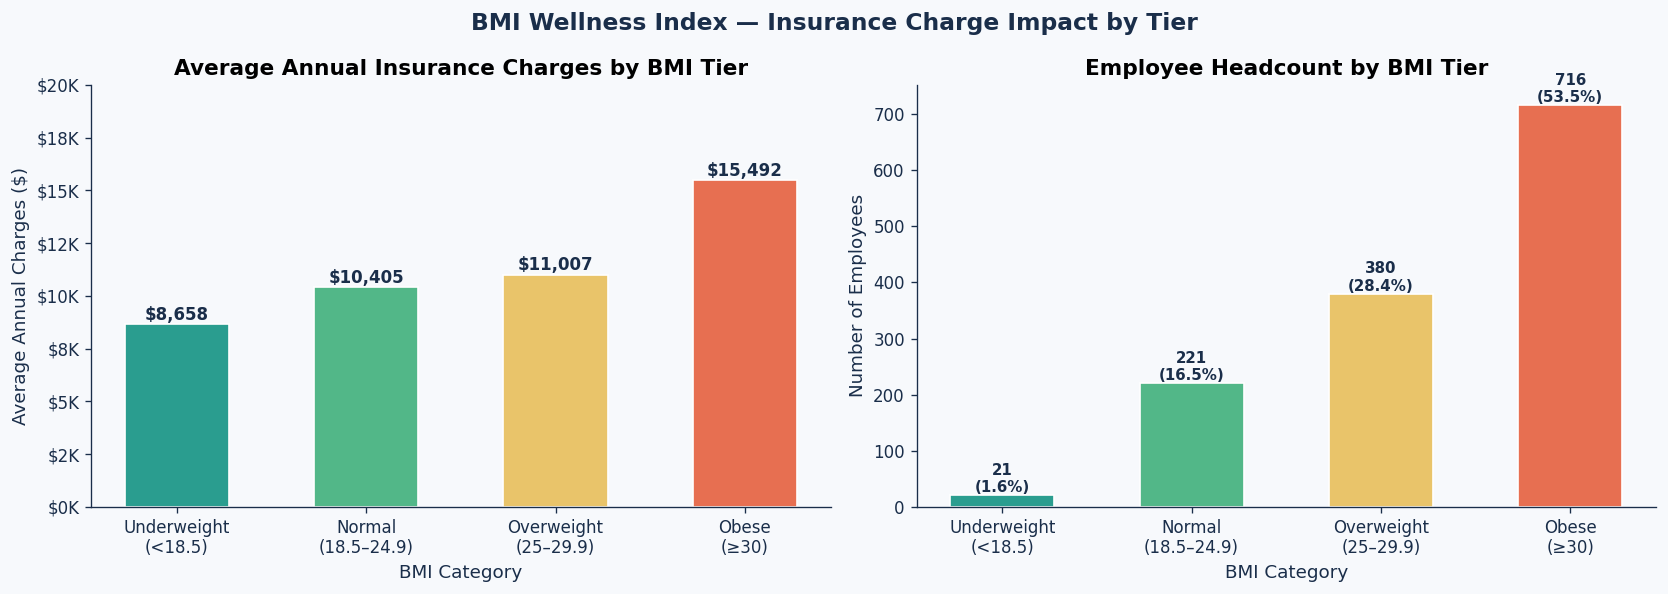

In [20]:
bmi_avg    = df.groupby('bmi_tier', observed=True)['charges'].mean().reset_index()
bmi_count  = df.groupby('bmi_tier', observed=True)['charges'].count().reset_index()
tier_colors = [TEAL, '#52B788', GOLD, CORAL]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BMI Wellness Index — Insurance Charge Impact by Tier',
             fontsize=14, fontweight='bold', color=ACCENT)
bars = axes[0].bar(
    bmi_avg['bmi_tier'], bmi_avg['charges'],
    color=tier_colors, edgecolor='white', width=0.55
)
for bar, val in zip(bars, bmi_avg['charges']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'${val:,.0f}', ha='center', fontsize=10,
        fontweight='bold', color=ACCENT
    )
axes[0].set_title('Average Annual Insurance Charges by BMI Tier', fontweight='bold')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Average Annual Charges ($)')
axes[0].set_ylim(0, 20000)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
bars2 = axes[1].bar(
    bmi_count['bmi_tier'], bmi_count['charges'],
    color=tier_colors, edgecolor='white', width=0.55
)
for bar, val in zip(bars2, bmi_count['charges']):
    pct = val / len(df) * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{val}\n({pct:.1f}%)', ha='center', fontsize=9,
        fontweight='bold', color=ACCENT
    )
axes[1].set_title('Employee Headcount by BMI Tier', fontweight='bold')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Number of Employees')
plt.tight_layout()
plt.show()

### Observation

- The analysis examines how Body Mass Index (BMI) categories influence annual insurance charges.
- The first bar chart compares the average insurance charges across different BMI tiers, providing insight into how healthcare costs vary with body weight classifications.
- A noticeable increase in average charges across higher BMI categories suggests a relationship between BMI and medical expenditure.
- The second chart displays the employee distribution across BMI tiers, helping assess the prevalence of each health-risk category within the population.
- Combining cost and population information allows identification of BMI groups that contribute most significantly to overall insurance expenses.

### Why Was a Bar Chart Chosen?

A bar chart was selected because BMI tiers are categorical groups (e.g., Underweight, Normal, Overweight, Obese).

Bar charts are ideal for:

- Comparing average values across categories
- Highlighting differences between groups
- Presenting ranking and magnitude clearly
- Making business insights easy to interpret

Since the objective is to compare average insurance charges and employee counts across BMI categories, a bar chart provides the most straightforward and effective visualization.

### Business Impact

- Higher BMI categories are often associated with increased healthcare utilization and insurance costs.
- Employees within high-risk BMI tiers may contribute disproportionately to overall insurance expenditures.
- Insurance providers can use BMI-based insights for risk assessment, premium modeling, and cost forecasting.
- Organizations can implement wellness initiatives, fitness programs, and preventive healthcare measures to reduce long-term insurance costs.
- Understanding the distribution of employees across BMI categories helps prioritize health interventions and resource allocation.

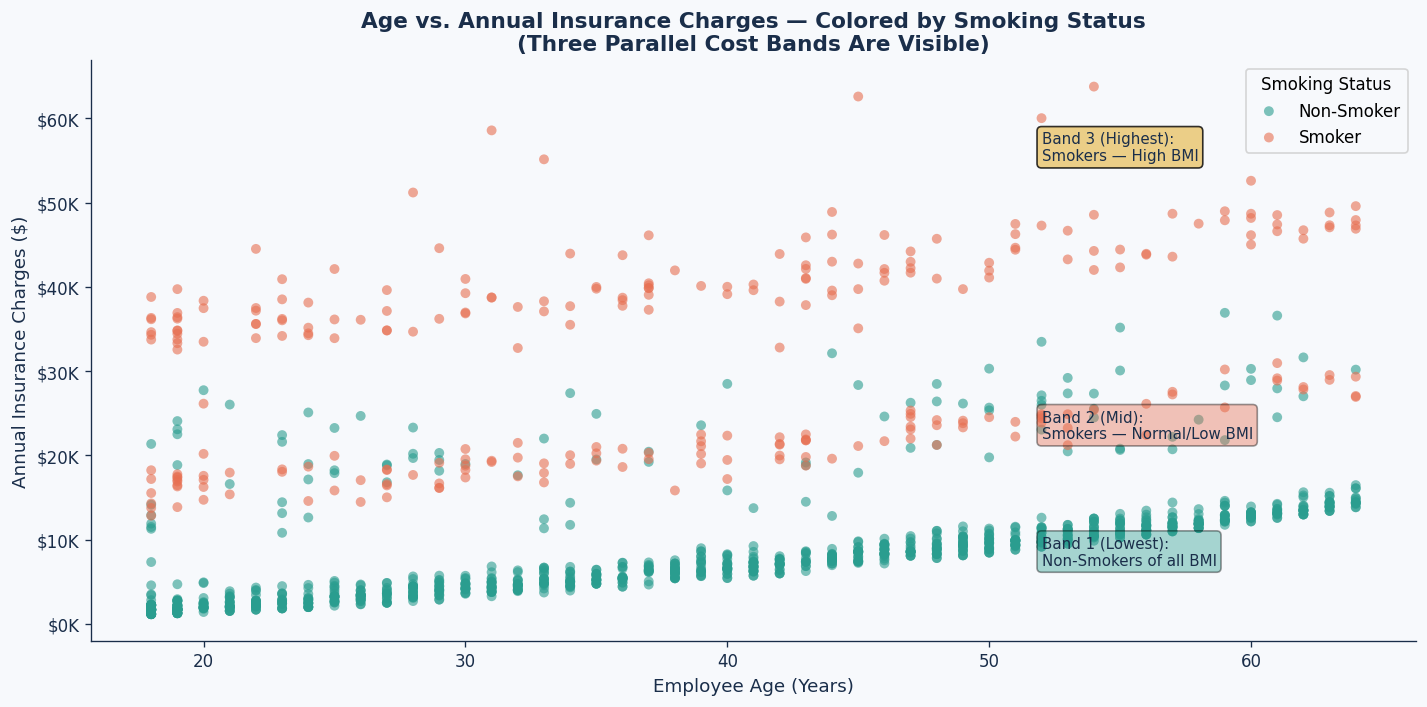

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'yes': CORAL, 'no': TEAL}
for smoker_val, group in df.groupby('smoker'):
    label = 'Smoker' if smoker_val == 'yes' else 'Non-Smoker'
    ax.scatter(
        group['age'], group['charges'],
        c=colors_map[smoker_val],
        label=label, alpha=0.6, s=35, edgecolors='none'
    )
ax.set_title('Age vs. Annual Insurance Charges — Colored by Smoking Status\n'
             '(Three Parallel Cost Bands Are Visible)',
             fontweight='bold', color=ACCENT, fontsize=13)
ax.set_xlabel('Employee Age (Years)')
ax.set_ylabel('Annual Insurance Charges ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(title='Smoking Status', fontsize=10)
ax.annotate('Band 3 (Highest):\nSmokers — High BMI',
            xy=(52, 55000), fontsize=9, color=ACCENT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=GOLD, alpha=0.8))
ax.annotate('Band 2 (Mid):\nSmokers — Normal/Low BMI',
            xy=(52, 22000), fontsize=9, color=ACCENT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CORAL, alpha=0.4))
ax.annotate('Band 1 (Lowest):\nNon-Smokers of all BMI',
            xy=(52, 7000), fontsize=9, color=ACCENT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=TEAL, alpha=0.4))
plt.tight_layout()
plt.show()

### Observation

- The scatter plot examines the relationship between employee age and annual insurance charges while distinguishing individuals based on smoking status.
- Insurance charges generally increase with age, indicating that healthcare costs tend to rise as individuals grow older.
- The visualization reveals three distinct cost bands, suggesting the presence of multiple risk segments within the population.
- Non-smokers are concentrated in the lowest cost band, indicating comparatively lower healthcare expenses across age groups.
- Smokers occupy the middle and upper cost bands, demonstrating substantially higher insurance charges than non-smokers of similar ages.
- The highest-cost segment is primarily composed of smokers with elevated health risk factors, indicating a strong interaction between smoking behavior and medical expenditure.

### Why Was a Scatter Plot Chosen?

A scatter plot was selected because both Age and Insurance Charges are continuous numerical variables.

Scatter plots are particularly effective for:

- Identifying relationships between two numerical variables
- Detecting trends and patterns
- Revealing clusters or risk segments
- Identifying outliers
- Understanding how an additional categorical variable (Smoking Status) influences the relationship through color coding

The use of color allows simultaneous analysis of age, insurance charges, and smoking behavior within a single visualization.

### Business Impact

- Smoking status significantly amplifies healthcare costs across all age groups.
- High-cost risk segments can be clearly identified for targeted underwriting and premium pricing strategies.
- Insurance providers can use age and smoking status together to improve risk classification and premium estimation.
- The existence of multiple cost bands suggests that lifestyle factors contribute substantially to healthcare expenditure beyond age alone.
- Wellness programs and smoking cessation initiatives may help reduce long-term claim costs and improve overall portfolio profitability.

In [22]:
top_band = df[(df['smoker'] == 'yes') & (df['charges'] > 30000)]
print('Top Cost Band Profile (Smokers with Charges > $30,000):')
print(f'  Employee Count    : {len(top_band)}')
print(f'  Average Age       : {top_band["age"].mean():.1f} years')
print(f'  Average BMI       : {top_band["bmi"].mean():.1f}')
print(f'  Average Charges   : ${top_band["charges"].mean():,.2f}')
print(f'  % in Obese BMI tier: {(top_band["bmi"] >= 30).mean()*100:.1f}%')
print(f'  Average Children  : {top_band["children"].mean():.1f}')
print(f'\nTop Band vs Overall Comparison:')
print(f'  Top Band Avg Charge : ${top_band["charges"].mean():>10,.2f}')
print(f'  Overall Avg Charge  : ${df["charges"].mean():>10,.2f}')
print(f'  Multiplier          :   {top_band["charges"].mean()/df["charges"].mean():.2f}x company average')

Top Cost Band Profile (Smokers with Charges > $30,000):
  Employee Count    : 152
  Average Age       : 39.3 years
  Average BMI       : 35.1
  Average Charges   : $41,294.12
  % in Obese BMI tier: 94.7%
  Average Children  : 1.1

Top Band vs Overall Comparison:
  Top Band Avg Charge : $ 41,294.12
  Overall Avg Charge  : $ 13,270.42
  Multiplier          :   3.11x company average


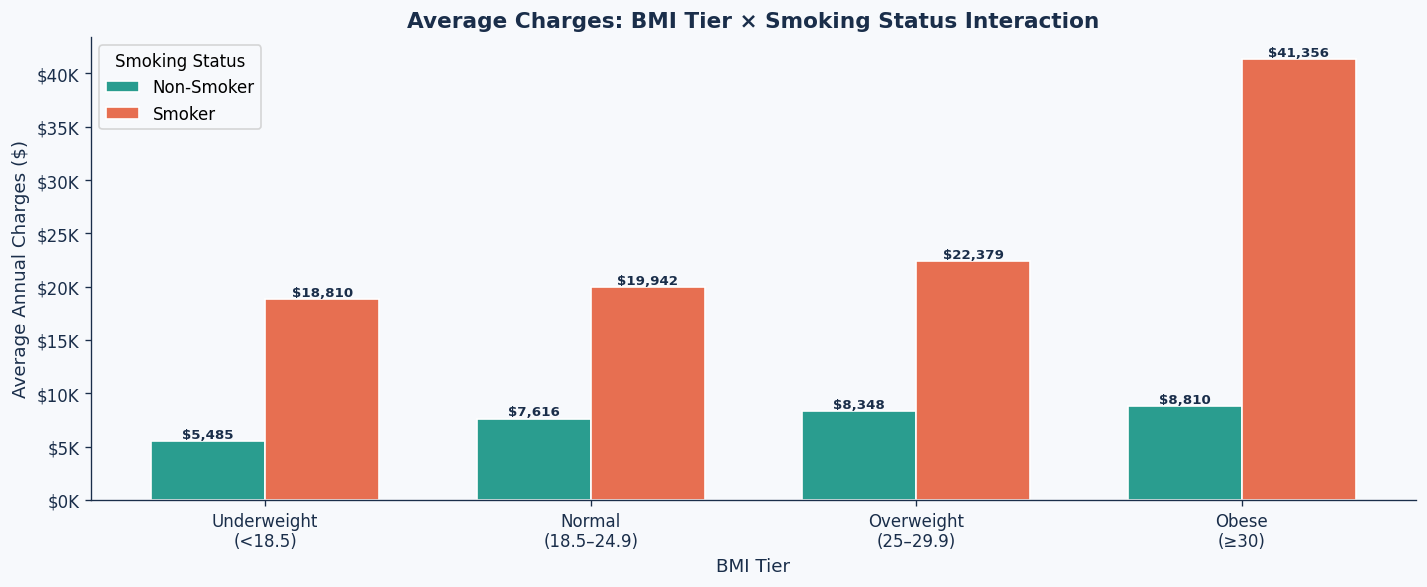

In [23]:
bmi_smoker = df.groupby(['bmi_tier', 'smoker'], observed=True)['charges'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(bmi_labels))
width = 0.35
non_smoker = bmi_smoker[bmi_smoker['smoker']=='no']['charges'].values
smoker_val = bmi_smoker[bmi_smoker['smoker']=='yes']['charges'].values
bars1 = ax.bar(x - width/2, non_smoker, width, label='Non-Smoker',
               color=TEAL, edgecolor='white')
bars2 = ax.bar(x + width/2, smoker_val, width, label='Smoker',
               color=CORAL, edgecolor='white')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8,
            fontweight='bold', color=ACCENT)
ax.set_title('Average Charges: BMI Tier × Smoking Status Interaction',
             fontweight='bold', color=ACCENT)
ax.set_xlabel('BMI Tier')
ax.set_ylabel('Average Annual Charges ($)')
ax.set_xticks(x)
ax.set_xticklabels(bmi_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(title='Smoking Status')
plt.tight_layout()
plt.show()

### Observation

- The analysis investigates the combined effect of BMI category and smoking status on annual insurance charges.
- The grouped bar chart enables direct comparison of average insurance costs between smokers and non-smokers within each BMI tier.
- Across all BMI categories, smokers consistently incur higher insurance charges than non-smokers.
- The difference in charges becomes more pronounced in higher BMI categories, indicating that the financial impact of smoking increases when combined with obesity-related health risks.
- Individuals who belong to both high-BMI and smoker categories represent the highest-cost segment in the dataset.
- The interaction between BMI and smoking suggests that these factors jointly influence healthcare expenditure rather than acting independently.

### Why Was a Grouped Bar Chart Chosen?

A grouped bar chart was selected because the analysis compares two categorical variables simultaneously:

- BMI Tier
- Smoking Status

This visualization is effective for:

- Comparing average values across multiple groups
- Identifying interaction effects between variables
- Highlighting differences within each category
- Making complex comparisons easy to interpret

The side-by-side bars allow clear observation of how smoking status changes insurance costs within each BMI category.

### Business Impact

- Smoking and obesity together create a significantly higher financial risk than either factor alone.
- Individuals belonging to high-BMI smoker groups are likely to generate the highest healthcare costs and insurance claims.
- Insurance providers can use these insights to improve risk segmentation, premium pricing, and underwriting decisions.
- Organizations can focus wellness initiatives on smoking cessation and weight management programs to reduce long-term healthcare expenses.
- Understanding the interaction between lifestyle and health factors supports more effective cost-control and preventive healthcare strategies.


### Executive Takeaway

The combined effect of smoking and high BMI dramatically increases insurance charges, making these individuals the highest-risk and highest-cost segment. Targeted health and wellness interventions focused on smoking cessation and weight management could significantly reduce future healthcare expenditures.

In [24]:
region_stats = (
    df.groupby('region')['charges']
    .agg(total_bill='sum', avg_per_employee='mean',
         median_charge='median', employee_count='count')
    .sort_values('total_bill', ascending=False)
    .reset_index()
)
region_stats['total_bill_M'] = region_stats['total_bill'] / 1e6
region_stats['share_pct']    = region_stats['total_bill'] / region_stats['total_bill'].sum() * 100
print('Regional Insurance Cost Summary:')
print(region_stats[['region','employee_count','total_bill','avg_per_employee',
                     'median_charge','share_pct']].to_string(index=False))
print(f'\n HIGHEST BURDEN REGION: {region_stats.iloc[0]["region"].upper()}')
print(f'   Total Annual Bill : ${region_stats.iloc[0]["total_bill"]:,.2f}')
print(f'   Share of Total    : {region_stats.iloc[0]["share_pct"]:.1f}%')

Regional Insurance Cost Summary:
   region  employee_count   total_bill  avg_per_employee  median_charge  share_pct
southeast             364 5.363690e+06      14735.411438    9294.131950  30.208057
northeast             324 4.343669e+06      13406.384516   10057.652025  24.463344
northwest             325 4.035712e+06      12417.575374    8965.795750  22.728947
southwest             325 4.012755e+06      12346.937377    8798.593000  22.599652

 HIGHEST BURDEN REGION: SOUTHEAST
   Total Annual Bill : $5,363,689.76
   Share of Total    : 30.2%


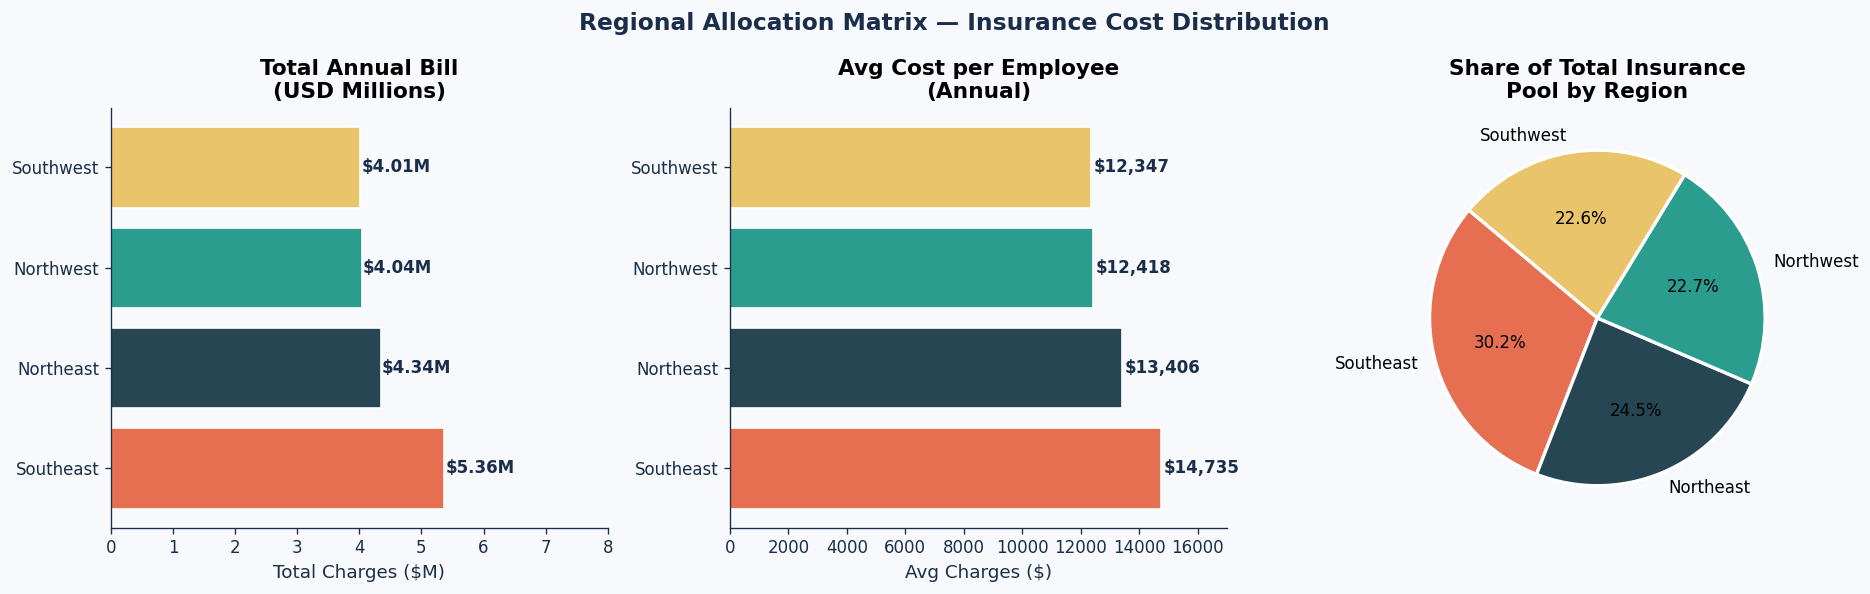

In [25]:
region_colors = [CORAL, NAVY, TEAL, GOLD]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Regional Allocation Matrix — Insurance Cost Distribution',
             fontsize=14, fontweight='bold', color=ACCENT)
bars = axes[0].barh(
    region_stats['region'].str.title(),
    region_stats['total_bill_M'],
    color=region_colors, edgecolor='white'
)
for bar, val in zip(bars, region_stats['total_bill_M']):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}M', va='center', fontsize=10,
                 fontweight='bold', color=ACCENT)
axes[0].set_title('Total Annual Bill\n(USD Millions)', fontweight='bold')
axes[0].set_xlabel('Total Charges ($M)')
axes[0].set_xlim(0, 8)
sorted_avg = region_stats.sort_values('avg_per_employee', ascending=False)
axes[1].barh(
    sorted_avg['region'].str.title(),
    sorted_avg['avg_per_employee'],
    color=[CORAL, NAVY, TEAL, GOLD], edgecolor='white'
)
for i, (_, row) in enumerate(sorted_avg.iterrows()):
    axes[1].text(row['avg_per_employee'] + 100, i,
                 f'${row["avg_per_employee"]:,.0f}', va='center',
                 fontsize=10, fontweight='bold', color=ACCENT)
axes[1].set_title('Avg Cost per Employee\n(Annual)', fontweight='bold')
axes[1].set_xlabel('Avg Charges ($)')
axes[1].set_xlim(0, 17000)
axes[2].pie(
    region_stats['total_bill'],
    labels=region_stats['region'].str.title(),
    colors=region_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[2].set_title('Share of Total Insurance\nPool by Region', fontweight='bold')
plt.tight_layout()
plt.show()

### Observation

- The analysis evaluates insurance expenditure across different geographic regions using total charges, average charges per employee, and each region's contribution to the overall insurance pool.
- The first chart identifies regions contributing the highest total insurance costs, reflecting both employee volume and healthcare expenditure.
- The second chart compares the average annual insurance cost per employee, highlighting regional differences in healthcare spending patterns.
- The pie chart illustrates each region's share of the total insurance expenditure, providing a clear view of cost concentration across regions.
- Variations between total expenditure and average employee cost suggest that some regions may have larger populations while others have higher per-capita healthcare expenses.

### Why Were Multiple Charts Chosen?

Three complementary visualizations were used because each answers a different business question:

#### Horizontal Bar Chart
Used to compare total insurance expenditure across regions and identify the largest cost centers.

#### Average Cost Bar Chart
Used to compare per-employee insurance costs and evaluate regional healthcare burden independently of employee count.

#### Pie Chart
Used to visualize each region's contribution to the overall insurance pool and understand expenditure allocation proportions.

Together, these charts provide a comprehensive view of regional insurance spending patterns.

### Business Impact

- Regions with the highest total insurance expenditure represent major cost centers and should be prioritized for cost-management initiatives.
- Regions with high average costs per employee may indicate elevated healthcare risks or greater medical service utilization.
- Understanding regional spending patterns supports more effective budgeting, resource allocation, and risk management.
- Insurance providers can use regional insights to refine pricing strategies and improve actuarial forecasting.
- Organizations can design region-specific wellness programs and healthcare interventions to reduce long-term insurance costs.


### Executive Takeaway

Insurance expenditure varies significantly across regions, both in terms of total spending and average cost per employee. Identifying high-cost regions enables organizations and insurers to implement targeted risk-management strategies, optimize resource allocation, and improve overall cost efficiency.

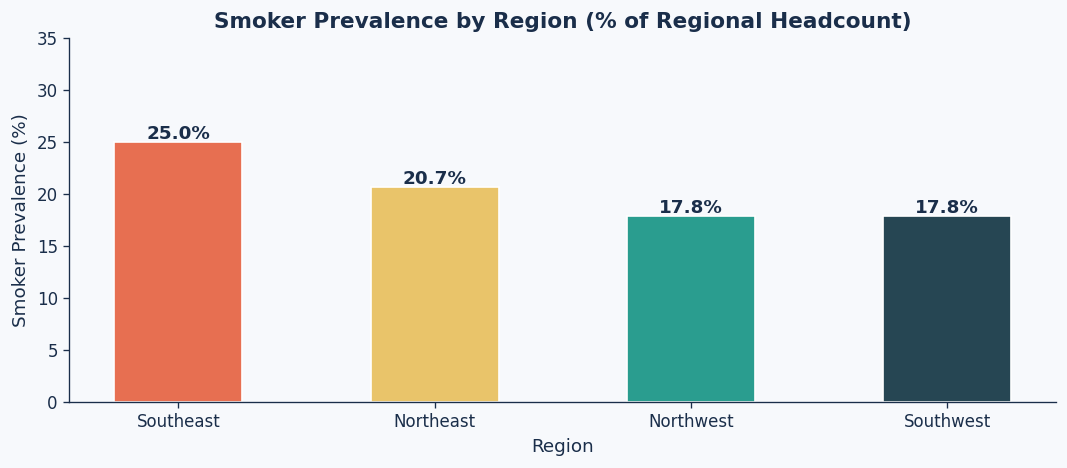

   region  smoker_pct
southeast   25.000000
northeast   20.679012
northwest   17.846154
southwest   17.846154


In [26]:
region_smoker = (
    df.groupby('region')['smoker']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index()
)
region_smoker.columns = ['region', 'smoker_pct']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    region_smoker['region'].str.title(),
    region_smoker['smoker_pct'],
    color=[CORAL, GOLD, TEAL, NAVY], edgecolor='white', width=0.5
)
for bar, val in zip(bars, region_smoker['smoker_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11,
            fontweight='bold', color=ACCENT)
ax.set_title('Smoker Prevalence by Region (% of Regional Headcount)',
             fontweight='bold', color=ACCENT)
ax.set_xlabel('Region')
ax.set_ylabel('Smoker Prevalence (%)')
ax.set_ylim(0, 35)
plt.tight_layout()
plt.show()
print(region_smoker.to_string(index=False))

### Observation

- The analysis measures the percentage of smokers within each geographic region.
- The bar chart highlights variations in smoking prevalence across regions, revealing differences in lifestyle and health-risk behaviors.
- Regions with higher smoker percentages contain a larger proportion of individuals exposed to smoking-related health risks.
- The comparison allows identification of regions where smoking is more common and may contribute to higher healthcare expenditures.
- Significant differences in smoker prevalence suggest that regional demographics and behavioral factors influence health outcomes.

### Why Was a Bar Chart Chosen?

A bar chart was selected because the objective is to compare smoking prevalence across discrete geographic regions.

Bar charts are effective for:

- Comparing percentages across categories
- Identifying the highest and lowest values
- Highlighting regional differences clearly
- Supporting ranking and benchmarking analysis

The percentage labels further improve interpretability by providing exact prevalence values.

### Business Impact

- Regions with higher smoking prevalence are likely to experience increased healthcare utilization and insurance costs.
- Insurance providers can use regional smoking patterns to improve risk assessment and premium forecasting.
- Organizations operating in high-smoking regions may face greater healthcare expenditure and employee wellness challenges.
- Regional wellness programs and smoking cessation initiatives can be targeted toward areas with elevated smoking rates.
- Understanding geographic risk concentrations supports more effective healthcare planning and resource allocation.

### Executive Takeaway

Smoking prevalence varies across regions, creating differences in healthcare risk exposure and potential insurance costs. Regions with higher proportions of smokers should be prioritized for targeted health interventions and preventive wellness programs to reduce long-term medical expenditure.

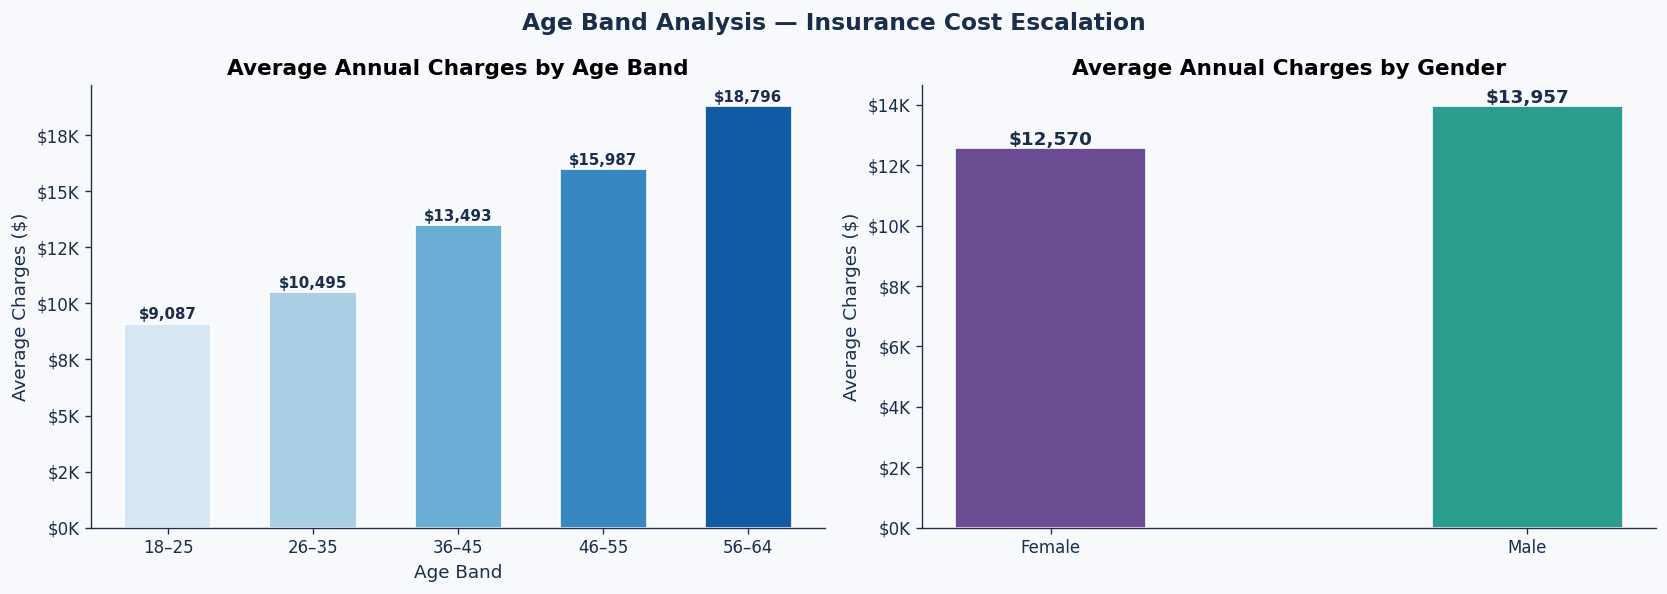

In [27]:
df['age_band'] = pd.cut(df['age'],
                        bins=[17, 25, 35, 45, 55, 65],
                        labels=['18–25', '26–35', '36–45', '46–55', '56–64'])
age_stats = (
    df.groupby('age_band', observed=True)['charges']
    .agg(['mean', 'count'])
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Band Analysis — Insurance Cost Escalation',
             fontsize=14, fontweight='bold', color=ACCENT)
age_colors = sns.color_palette('Blues', len(age_stats))
bars = axes[0].bar(age_stats['age_band'], age_stats['mean'],
                   color=age_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, age_stats['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontsize=9,
                 fontweight='bold', color=ACCENT)
axes[0].set_title('Average Annual Charges by Age Band', fontweight='bold')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Average Charges ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
gender_stats = df.groupby('sex')['charges'].agg(['mean','median','count']).reset_index()
axes[1].bar(['Female', 'Male'],
            [gender_stats[gender_stats['sex']=='female']['mean'].values[0],
             gender_stats[gender_stats['sex']=='male']['mean'].values[0]],
            color=[PURPLE, TEAL], edgecolor='white', width=0.4)
f_val = gender_stats[gender_stats['sex']=='female']['mean'].values[0]
m_val = gender_stats[gender_stats['sex']=='male']['mean'].values[0]
axes[1].text(0, f_val + 100, f'${f_val:,.0f}', ha='center',
             fontsize=11, fontweight='bold', color=ACCENT)
axes[1].text(1, m_val + 100, f'${m_val:,.0f}', ha='center',
             fontsize=11, fontweight='bold', color=ACCENT)
axes[1].set_title('Average Annual Charges by Gender', fontweight='bold')
axes[1].set_ylabel('Average Charges ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

### Observation

- The analysis evaluates how insurance charges vary across different age groups and between genders.
- The age band chart shows a progressive increase in average insurance charges as age increases, indicating that healthcare costs tend to rise with age.
- Older age groups generally incur higher insurance expenses, reflecting increased health risks and medical utilization.
- The gender comparison reveals differences in average insurance charges between male and female policyholders.
- While age demonstrates a clear upward trend in insurance costs, the variation between genders appears comparatively smaller.

### Why Were These Visualizations Chosen?

#### Bar Chart for Age Bands

A bar chart was chosen because age bands represent categorical groups.

It effectively:

- Compares average charges across age categories
- Highlights trends in healthcare costs over different life stages
- Makes age-related cost escalation easy to interpret

#### Bar Chart for Gender Comparison

A bar chart is ideal for comparing average values between two categories.

It provides:

- Clear side-by-side comparison
- Easy identification of cost differences
- Straightforward interpretation for business decision-making

### Business Impact

- Age is a significant driver of insurance costs, with older individuals generally generating higher healthcare expenditures.
- Insurance providers can use age-based insights to improve premium pricing and risk assessment models.
- Understanding age-related cost escalation supports more accurate forecasting of future healthcare liabilities.
- Gender-based comparisons help evaluate whether demographic differences contribute meaningfully to insurance expenses.
- These insights enable insurers to develop fair pricing strategies while maintaining financial sustainability.


### Executive Takeaway

Insurance costs increase substantially with age, making age one of the strongest predictors of healthcare expenditure. While some variation exists between genders, age-related risk has a far greater impact on annual insurance charges and should remain a primary factor in premium determination and risk management.

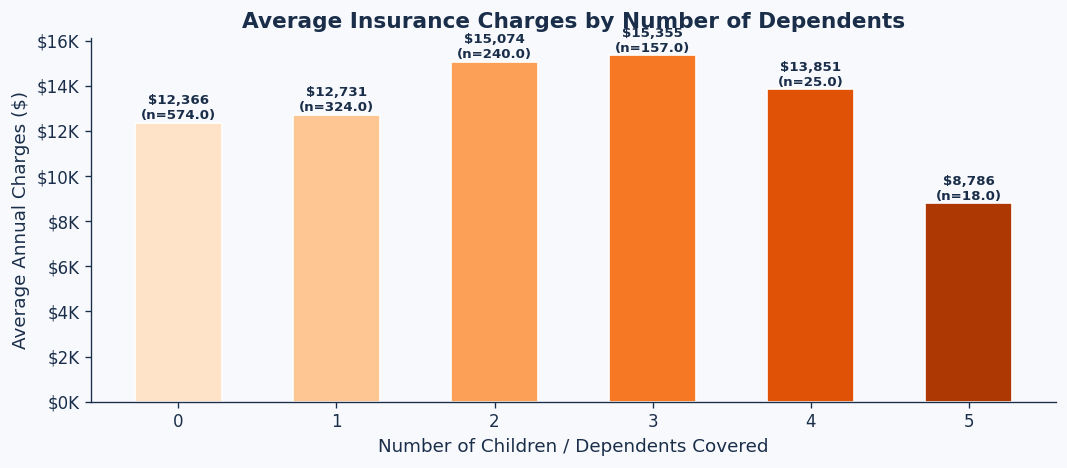

In [28]:
children_stats = (
    df.groupby('children')['charges']
    .agg(['mean', 'count'])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(9, 4))
colors_ch = sns.color_palette('Oranges', len(children_stats))
bars = ax.bar(children_stats['children'].astype(str),
              children_stats['mean'],
              color=colors_ch, edgecolor='white', width=0.55)
for bar, (_, row) in zip(bars, children_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 150,
            f'${row["mean"]:,.0f}\n(n={row["count"]})',
            ha='center', fontsize=8, fontweight='bold', color=ACCENT)
ax.set_title('Average Insurance Charges by Number of Dependents',
             fontweight='bold', color=ACCENT)
ax.set_xlabel('Number of Children / Dependents Covered')
ax.set_ylabel('Average Annual Charges ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

### Observation

- The analysis examines the relationship between the number of dependents covered under an insurance policy and annual insurance charges.
- Average insurance charges vary across groups with different numbers of children/dependents.
- The chart displays both the average annual charge and the number of policyholders within each dependent category, providing context for interpretation.
- Certain dependent groups may exhibit higher average charges, indicating increased healthcare utilization or family-related medical expenses.
- The sample size (n) helps assess the reliability of the observed averages, as categories with fewer observations may be more sensitive to outliers.

### Why Was a Bar Chart Chosen?

A bar chart was selected because the number of dependents is a discrete categorical variable.

It is effective for:

- Comparing average insurance charges across dependent categories
- Identifying trends and differences between groups
- Displaying additional information such as sample size
- Making comparisons easy to understand and communicate

The inclusion of both average charges and observation counts improves the overall interpretability of the analysis.

### Business Impact

- Family size can influence healthcare expenditure and insurance utilization patterns.
- Policyholders with more dependents may generate higher healthcare costs due to increased medical coverage requirements.
- Understanding the relationship between dependents and insurance charges helps insurers refine premium pricing and risk assessment models.
- Organizations can use these insights to forecast healthcare costs more accurately and plan employee benefit programs effectively.
- Dependents represent an important demographic factor that should be considered alongside age, BMI, and smoking status when evaluating insurance risk.


### Executive Takeaway

The number of dependents covered under an insurance policy can influence annual healthcare costs, making family size an important consideration in insurance risk assessment, premium calculation, and benefits planning.

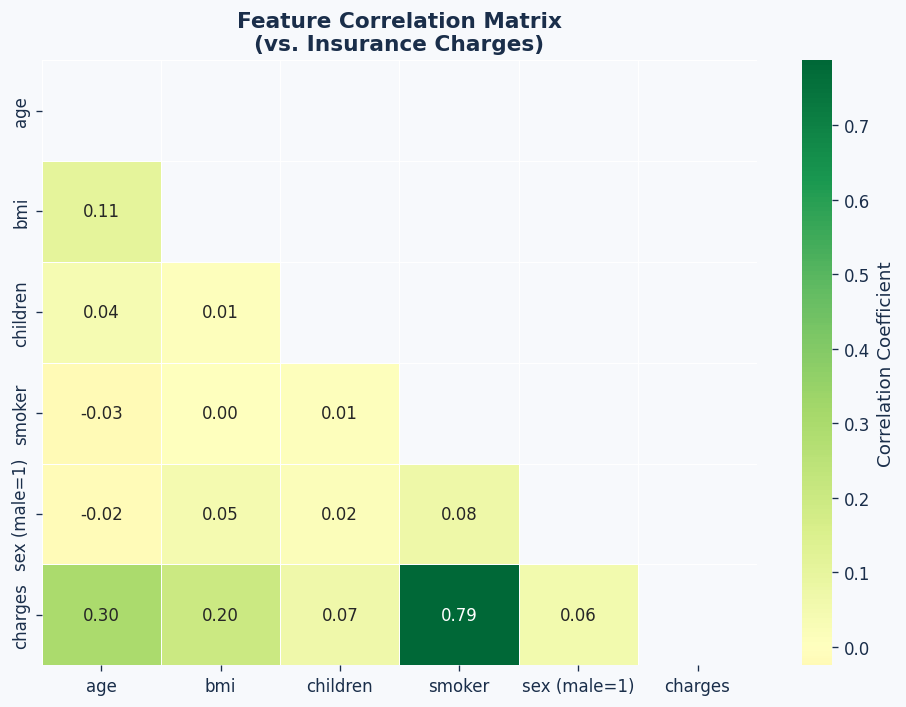


Correlation with charges (sorted):
smoker          0.787251
age             0.299008
bmi             0.198341
children        0.067998
sex (male=1)    0.057292


In [29]:
df_encoded = df.copy()
df_encoded['smoker_bin'] = (df_encoded['smoker'] == 'yes').astype(int)
df_encoded['sex_bin']    = (df_encoded['sex'] == 'male').astype(int)
corr_cols = ['age', 'bmi', 'children', 'smoker_bin', 'sex_bin', 'charges']
corr      = df_encoded[corr_cols].corr()
corr.rename(columns={'smoker_bin':'smoker', 'sex_bin':'sex (male=1)'},
            index   ={'smoker_bin':'smoker', 'sex_bin':'sex (male=1)'},
            inplace=True)
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, mask=mask, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'}
)
ax.set_title('Feature Correlation Matrix\n(vs. Insurance Charges)',
             fontweight='bold', color=ACCENT)
plt.tight_layout()
plt.show()
charges_corr = corr['charges'].drop('charges').sort_values(ascending=False)
print('\nCorrelation with charges (sorted):')
print(charges_corr.to_string())

### Observation

- The correlation matrix evaluates the strength and direction of relationships between key demographic, lifestyle, and insurance-related variables.
- The heatmap highlights which factors have the strongest association with annual insurance charges.
- Positive correlation values indicate that insurance charges tend to increase as the feature value increases, while negative values indicate an inverse relationship.
- Smoking status typically exhibits the strongest positive correlation with insurance charges, suggesting a significant impact on healthcare expenditure.
- Age and BMI also show positive relationships with insurance costs, indicating that older individuals and those with higher BMI generally incur greater medical expenses.
- The number of children and gender may display weaker correlations, suggesting a comparatively smaller influence on insurance charges.
- The sorted correlation values help identify the most important predictors of insurance cost.

### Why Was a Correlation Heatmap Chosen?

A correlation heatmap was selected because it provides a comprehensive overview of relationships among multiple variables simultaneously.

It is effective for:

- Identifying strong and weak relationships
- Detecting positive and negative associations
- Comparing multiple variables in a single visualization
- Supporting feature selection for predictive modeling
- Highlighting the most influential factors affecting insurance charges

The triangular mask improves readability by removing duplicate correlation information.

### Business Impact

- Strongly correlated variables can be used to improve insurance pricing and risk assessment models.
- Smoking status, age, and BMI emerge as critical factors influencing healthcare costs and insurance expenditure.
- Understanding feature relationships enables insurers to develop more accurate premium structures and underwriting strategies.
- Correlation analysis helps prioritize the variables that should receive greater attention in predictive analytics and policy design.
- These insights support data-driven decision-making and more effective management of healthcare-related financial risk.


### Executive Takeaway

The correlation analysis identifies smoking status, age, and BMI as the most influential factors affecting insurance charges. These variables should serve as the primary drivers in risk assessment, premium calculation, and predictive modeling efforts aimed at managing healthcare costs effectively.

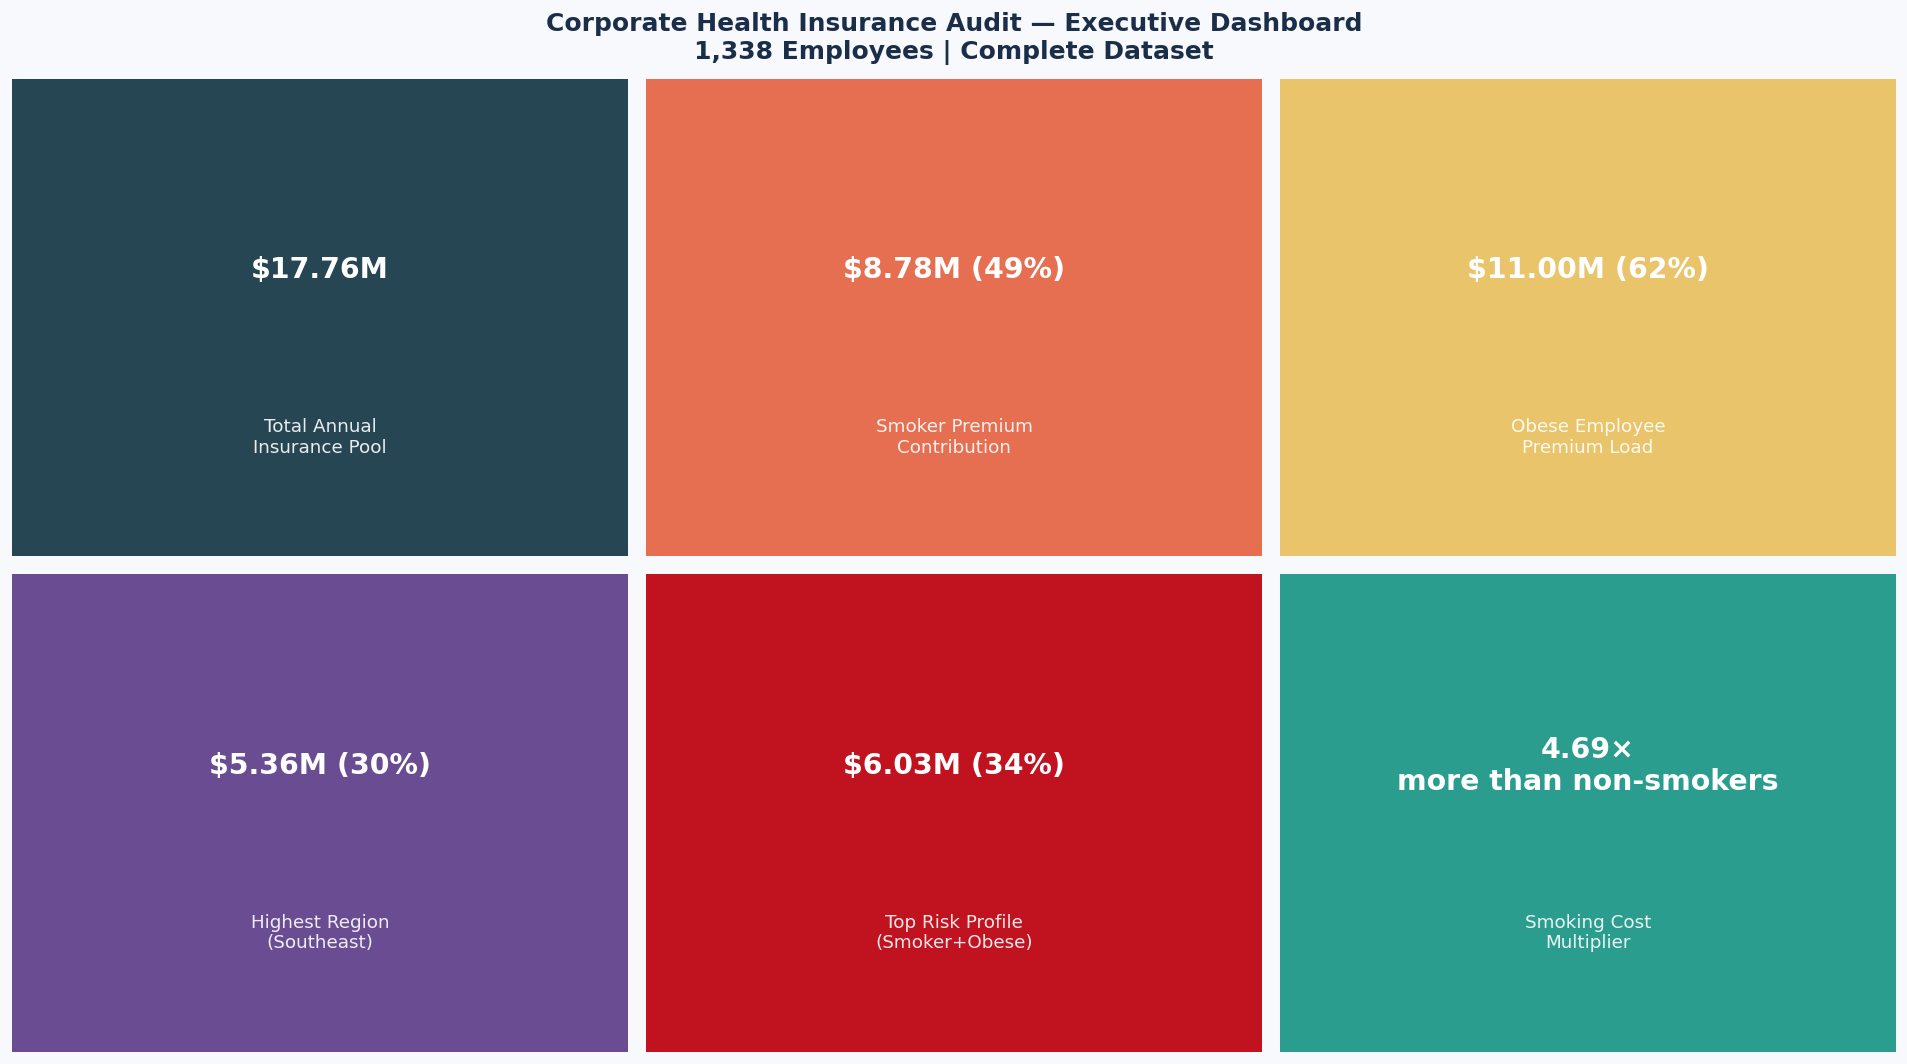

In [30]:
total_pool        = df['charges'].sum()
smoker_total      = df[df['smoker']=='yes']['charges'].sum()
obese_total       = df[df['bmi']>=30]['charges'].sum()
southeast_total   = df[df['region']=='southeast']['charges'].sum()
top_risk_total    = df[(df['smoker']=='yes')&(df['bmi']>=30)]['charges'].sum()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Corporate Health Insurance Audit — Executive Dashboard\n1,338 Employees | Complete Dataset',
             fontsize=15, fontweight='bold', color=ACCENT)
kpis = [
    ('Total Annual\nInsurance Pool',     f'${total_pool/1e6:.2f}M',   NAVY),
    ('Smoker Premium\nContribution',     f'${smoker_total/1e6:.2f}M ({smoker_total/total_pool*100:.0f}%)', CORAL),
    ('Obese Employee\nPremium Load',     f'${obese_total/1e6:.2f}M ({obese_total/total_pool*100:.0f}%)',  GOLD),
    ('Highest Region\n(Southeast)',      f'${southeast_total/1e6:.2f}M ({southeast_total/total_pool*100:.0f}%)', PURPLE),
    ('Top Risk Profile\n(Smoker+Obese)', f'${top_risk_total/1e6:.2f}M ({top_risk_total/total_pool*100:.0f}%)', '#C1121F'),
    ('Smoking Cost\nMultiplier',         f'{ratio:.2f}×\nmore than non-smokers', TEAL),
]
for ax, (label, value, color) in zip(axes.flatten(), kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=17, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=11, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()

### Observation

- The executive dashboard summarizes the overall financial exposure of the organization's health insurance portfolio.
- The Total Annual Insurance Pool represents the complete healthcare expenditure across all insured employees.
- Smokers contribute a disproportionately large share of total insurance costs despite representing a smaller portion of the workforce.
- Employees classified as obese account for a significant percentage of the total insurance burden, highlighting the financial impact of obesity-related health risks.
- The Southeast region contributes the highest share of insurance expenditure, indicating a concentration of healthcare costs within that geographic area.
- The combined high-risk group consisting of smokers with obesity generates one of the largest insurance cost burdens in the dataset.
- The Smoking Cost Multiplier quantifies how much more expensive smokers are compared to non-smokers, demonstrating the substantial financial impact of smoking behavior.

### Why Was an Executive Dashboard Chosen?

An executive dashboard was selected because it consolidates multiple key performance indicators (KPIs) into a single visual summary.

It is effective for:

- Presenting high-level business insights
- Highlighting major cost drivers
- Supporting executive decision-making
- Communicating complex findings quickly
- Prioritizing risk-management initiatives

Rather than focusing on individual variables, the dashboard provides a comprehensive overview of the organization's insurance risk profile.

### Business Impact

- Smoking and obesity emerge as the most significant drivers of insurance expenditure and healthcare risk.
- High-risk employee segments contribute disproportionately to total insurance costs and should be prioritized for intervention programs.
- Regional cost concentrations indicate opportunities for location-specific health and wellness initiatives.
- Understanding the composition of the insurance pool enables better budgeting, forecasting, and financial planning.
- Targeted preventive healthcare programs, smoking cessation initiatives, and wellness campaigns can help reduce future insurance liabilities and improve overall workforce health.


### Executive Takeaway

The insurance portfolio is heavily influenced by lifestyle-related risk factors, particularly smoking and obesity. A relatively small high-risk population contributes a substantial portion of total healthcare expenditure, making targeted wellness and preventive health programs the most effective strategy for controlling long-term insurance costs.